In [9]:
from google.colab import files
uploaded = files.upload()

Saving hospital.csv to hospital (1).csv


In [10]:
!pip install plotly matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)

In [11]:
medical_df = pd.read_csv("hospital.csv", sep=",")

# Fix single column issue
medical_df = medical_df.iloc[:, 0].str.split(',', expand=True)
medical_df.columns = ['age', 'gender', 'bmi', 'children', 'smoker', 'region', 'charges']

# Convert numeric columns
medical_df['age']      = pd.to_numeric(medical_df['age'])
medical_df['bmi']      = pd.to_numeric(medical_df['bmi'])
medical_df['children'] = pd.to_numeric(medical_df['children'])
medical_df['charges']  = pd.to_numeric(medical_df['charges'])

print("Shape:", medical_df.shape)
medical_df.head()

Shape: (1338, 7)


,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [12]:
medical_df.info()
medical_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   gender    1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [13]:
fig = px.histogram(medical_df, x='age', marginal='box',
                   nbins=47, title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

In [14]:
fig = px.histogram(medical_df, x='bmi', marginal='box',
                   color_discrete_sequence=['red'],
                   title='Distribution of BMI (Body Mass Index)')
fig.update_layout(bargap=0.1)
fig.show()

In [15]:
fig = px.histogram(medical_df, x='bmi', marginal='box',
                   color_discrete_sequence=['red'],
                   title='Distribution of BMI (Body Mass Index)')
fig.update_layout(bargap=0.1)
fig.show()

In [16]:
fig = px.histogram(medical_df, x='charges', marginal='box',
                   color='smoker',
                   color_discrete_sequence=['green', 'grey'],
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

In [17]:
print(medical_df.smoker.value_counts())
px.histogram(medical_df, x='smoker', color='gender', title='Smoker')

smoker
no     1064
yes     274
Name: count, dtype: int64


In [18]:
fig = px.scatter(medical_df, x='age', y='charges',
                 color='smoker', opacity=0.8,
                 hover_data=['gender'],
                 title='Age vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

In [19]:
fig = px.scatter(medical_df, x='bmi', y='charges',
                 color='smoker', opacity=0.8,
                 hover_data=['gender'],
                 title='BMI vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

In [20]:
# Correlation with charges
print("Age vs Charges:", medical_df.charges.corr(medical_df.age))
print("BMI vs Charges:", medical_df.charges.corr(medical_df.bmi))

smoker_numeric = medical_df.smoker.map({'no': 0, 'yes': 1})
print("Smoker vs Charges:", medical_df.charges.corr(smoker_numeric))

Age vs Charges: 0.2990081933306476
BMI vs Charges: 0.19834096883362895
Smoker vs Charges: 0.787251430498478


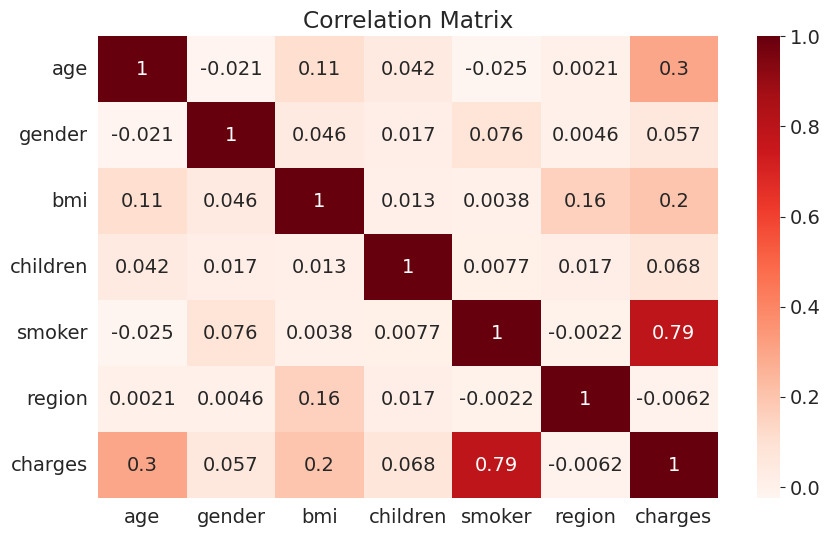

In [21]:
le = LabelEncoder()
medical_df["gender"] = le.fit_transform(medical_df["gender"])
medical_df["smoker"] = le.fit_transform(medical_df["smoker"])
medical_df["region"] = le.fit_transform(medical_df["region"])

# Correlation matrix
sns.heatmap(medical_df.corr(), cmap='Reds', annot=True)
plt.title('Correlation Matrix')
plt.show()

In [22]:
X = medical_df.drop('charges', axis=1)
y = medical_df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

predictions = lr.predict(X_test)
print("R² Score:", r2_score(y_test, predictions).round(4))
print("MAE:", mean_absolute_error(y_test, predictions).round(2))

AttributeError: 'float' object has no attribute 'round'

In [ ]:
# New patient: age=35, female(0), bmi=28, 2 children, non-smoker(0), southeast(2)
new_patient = pd.DataFrame([[35, 0, 28, 2, 0, 2]], columns=X.columns)
predicted = lr.predict(new_patient)[0]
print(f"Predicted Medical Charges: ${predicted:.2f}")